# Vetting the data

Every number the app shows comes from three seed files and the pipeline built on them. This
notebook checks each layer for gaps, duplicates and outliers before anyone trusts the calls.

- **Inputs:** branches (2GIS, hand-collected), communities (DSC census, hand-collected),
  competitors (OpenStreetMap, `scripts/fetch_competitors.py`)
- **Computed:** catchments, branch scores, area 2×2 and what's left in each area

Open it with `just notebook`. Each check prints what it found; the last section lists open
questions.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import settings
from src.features.assign import COMPETITOR_MAX_KM, haversine_km
from src.model import opportunity, rubric
from src.webapp.data import load_baseline
from src.webapp.map import ACTION_COLORS, OPPORTUNITY_COLORS

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
hexcolor = lambda rgb: "#%02x%02x%02x" % tuple(rgb[:3])
ACTION = {k: hexcolor(v) for k, v in ACTION_COLORS.items()}
AREA = {k: hexcolor(v) for k, v in OPPORTUNITY_COLORS.items()}

data = load_baseline(settings)          # the same baseline the app shows
seed = ROOT / "data" / "seed"
branches = pd.read_csv(seed / "branches.csv")
communities = pd.read_csv(seed / "communities.csv")
competitors = pd.read_csv(seed / "competitors.csv")
print(f"{len(branches)} branches · {len(communities)} communities · "
      f"{len(competitors)} competitors")

9 branches · 50 communities · 768 competitors


## 1. Inputs
### Branches

In [2]:
branches

,id,name,lat,lng,area,rating,review_count,avg_price_aed
0,al-barsha-2,Bedashing Beauty Lounge Al Barsha,25.1124,55.2044,Al Barsha 2,4.7,396.0,NaN
1,al-warqa,Bedashing Beauty Lounge Al Warqa City Mall,25.1900,55.3850,Al Warqa,4.7,280.0,NaN
2,city-walk,Bedashing Beauty Lounge City Walk,25.2038,55.2593,City Walk,4.6,454.0,NaN
3,jumeirah-park,Bedashing Beauty Lounge Jumeirah Park,25.0453,55.1531,Jumeirah Park,4.8,158.0,NaN
4,mirdif-35,Bedashing Beauty Lounge Mirdif 35,25.2160,55.4200,Mirdif,4.6,568.0,NaN
5,nad-al-sheba,Bedashing Beauty Lounge Nad Al Sheba,25.1750,55.3300,Nad Al Sheba,4.6,319.0,NaN
6,al-safa-2,Bedashing Beauty Lounge Al Safa 2,25.1858,55.2410,Al Safa 2,4.6,98.0,NaN
7,palm-jumeirah,Bedashing Beauty Lounge Palm Jumeirah,25.1130,55.1380,Palm Jumeirah,4.9,38.0,NaN
8,sheikh-zayed-road,Bedashing Beauty Lounge Sheikh Zayed Road,25.1180,55.2015,Al Barsha 1 (Sheikh Zayed Road),NaN,NaN,NaN


In [3]:
DUBAI = dict(lat=(24.7, 25.4), lng=(54.9, 55.7))
checks = {
    "missing rating": branches.loc[branches.rating.isna(), "id"].tolist(),
    "missing review count": branches.loc[branches.review_count.isna(), "id"].tolist(),
    "rating outside 1-5": branches.loc[~branches.rating.between(1, 5) & branches.rating.notna(), "id"].tolist(),
    "outside Dubai box": branches.loc[~branches.lat.between(*DUBAI["lat"]) | ~branches.lng.between(*DUBAI["lng"]), "id"].tolist(),
    "duplicate ids": branches.loc[branches.id.duplicated(), "id"].tolist(),
    "every price missing": bool(branches.avg_price_aed.isna().all()),
}
pd.Series(checks, name="finding").to_frame()

,finding
missing rating,[sheikh-zayed-road]
missing review count,[sheikh-zayed-road]
rating outside 1-5,[]
outside Dubai box,[]
duplicate ids,[]
every price missing,True


In [4]:
# Branches closer than 1 km to each other: both will fight over the same communities.
pairs = [(a.id, b.id, round(haversine_km(a.lat, a.lng, b.lat, b.lng), 2))
         for i, a in branches.iterrows() for j, b in branches.iterrows() if i < j]
pd.DataFrame(pairs, columns=["branch", "other", "km"]).sort_values("km").head(5)

,branch,other,km
7,al-barsha-2,sheikh-zayed-road,0.69
18,city-walk,al-safa-2,2.72
10,al-warqa,mirdif-35,4.56
11,al-warqa,nad-al-sheba,5.78
35,palm-jumeirah,sheikh-zayed-road,6.42


### Communities

In [5]:
communities["female_est"] = (communities.population_total * settings.global_female_share).round()
print("female population published for", communities.population_female.notna().sum(), "of",
      len(communities), "communities; the rest are estimated at",
      f"{settings.global_female_share:.0%}")
communities.describe().round(1)

female population published for 0 of 50 communities; the rest are estimated at 49%


,lat,lng,population_total,population_female,female_est
count,50.0,50.0,50.0,0.0,50.0
mean,25.2,55.3,46659.0,NaN,22862.9
std,0.1,0.1,37443.4,NaN,18347.3
min,25.0,55.1,6589.0,NaN,3229.0
25%,25.1,55.2,21587.5,NaN,10577.8
50%,25.2,55.3,39432.0,NaN,19321.5
75%,25.3,55.3,61536.8,NaN,30152.8
max,25.3,55.4,198228.0,NaN,97132.0


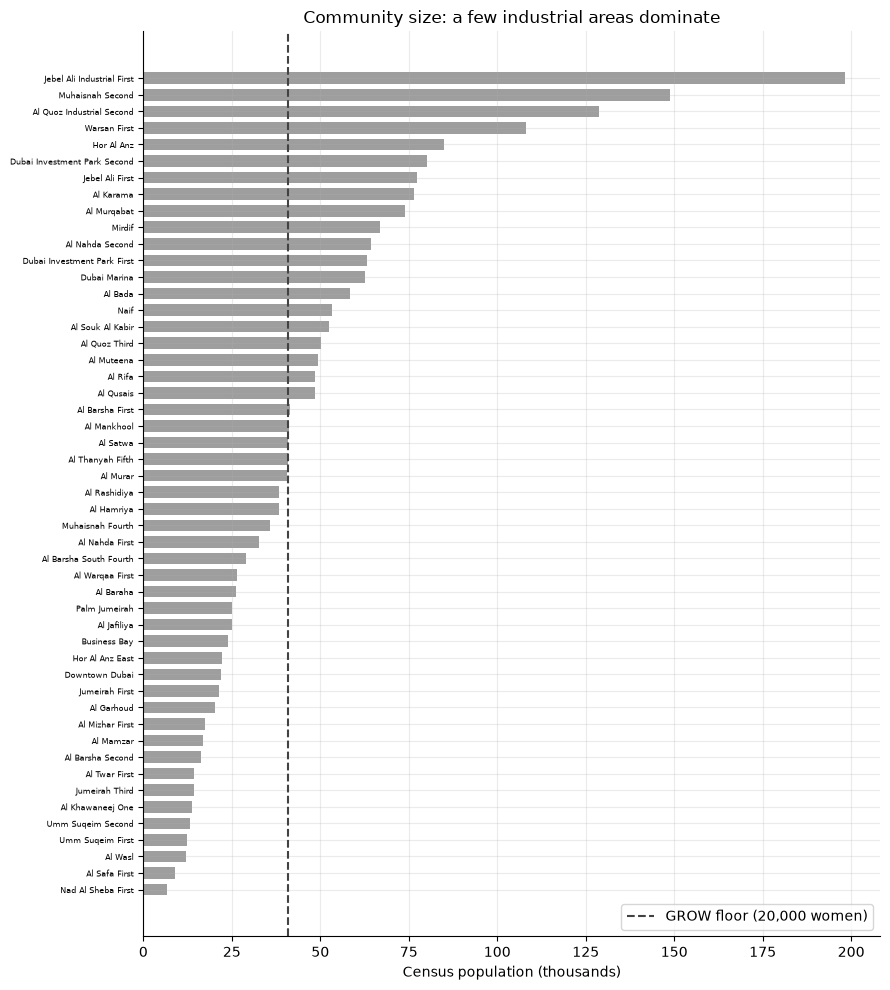

In [6]:
fig, ax = plt.subplots()
ordered = communities.sort_values("population_total")
ax.barh(ordered.name_en, ordered.population_total / 1000, color="#9e9e9e", height=0.7)
ax.axvline(opportunity.MIN_POP / settings.global_female_share / 1000, color="#424242", lw=1.5,
           ls="--", label=f"GROW floor ({opportunity.MIN_POP:,} women)")
ax.set_xlabel("Census population (thousands)")
ax.set_title("Community size: a few industrial areas dominate")
ax.tick_params(axis="y", labelsize=6)
ax.legend(loc="lower right")
fig.set_size_inches(9, 10)
plt.tight_layout()
plt.show()

In [7]:
industrial = communities[communities.name_en.str.contains("Industrial|Investment Park", case=False)]
print(f"{len(industrial)} industrial / worker-housing communities hold "
      f"{industrial.population_total.sum() / communities.population_total.sum():.0%} of the population")
industrial[["name_en", "population_total", "female_est"]]

4 industrial / worker-housing communities hold 20% of the population


,name_en,population_total,female_est
0,Jebel Ali Industrial First,198228,97132.0
2,Al Quoz Industrial Second,128867,63145.0
5,Dubai Investment Park Second,80118,39258.0
11,Dubai Investment Park First,63094,30916.0


### Competitors

In [8]:
competitors["category"].value_counts().rename("count").to_frame()

,count
category,
beauty,418
hairdresser,350


In [9]:
import re
male = re.compile(r"\b(?:gents?|men|man|barbers?|barbershop)\b", re.I)
unnamed = competitors.name.isna() | (competitors.name.fillna("").str.strip() == "")
dup_names = competitors[competitors.name.notna() & competitors.duplicated("name", keep=False)]
pd.Series({
    "unnamed": int(unnamed.sum()),
    "male-only names still present": int(competitors.name.fillna("").str.contains(male).sum()),
    "names appearing more than once": dup_names.name.nunique(),
    "same name within 50 m (likely duplicates)": sum(
        haversine_km(a.lat, a.lng, b.lat, b.lng) < 0.05
        for _, g in dup_names.groupby("name") for i, a in g.iterrows() for j, b in g.iterrows() if i < j),
}, name="finding").to_frame()

,finding
unnamed,38
male-only names still present,0
names appearing more than once,24
same name within 50 m (likely duplicates),3


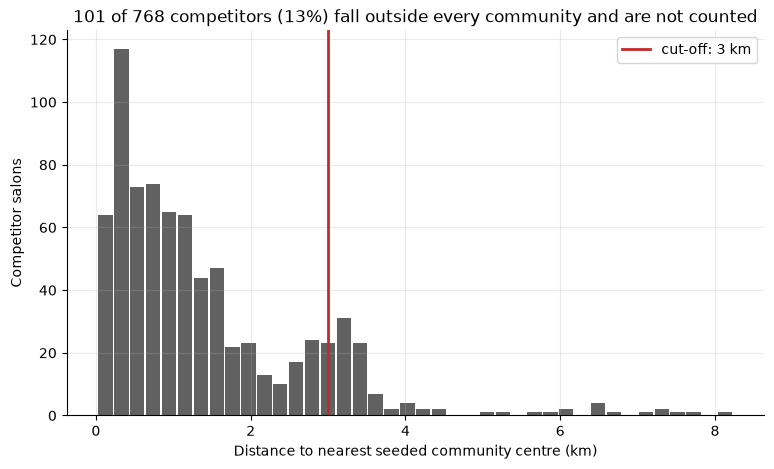

In [10]:
# How far each competitor is from its nearest community centre, and what the 3 km cut-off drops.
nearest_km = competitors.apply(lambda k: min(
    haversine_km(k.lat, k.lng, c.lat, c.lng) for c in communities.itertuples()), axis=1)
dropped = (nearest_km > COMPETITOR_MAX_KM).sum()
fig, ax = plt.subplots()
ax.hist(nearest_km, bins=40, color="#616161", rwidth=0.9)
ax.axvline(COMPETITOR_MAX_KM, color="#c62828", lw=2, label=f"cut-off: {COMPETITOR_MAX_KM:g} km")
ax.set_xlabel("Distance to nearest seeded community centre (km)")
ax.set_ylabel("Competitor salons")
ax.set_title(f"{dropped} of {len(competitors)} competitors ({dropped / len(competitors):.0%}) "
             "fall outside every community and are not counted")
ax.legend()
plt.show()

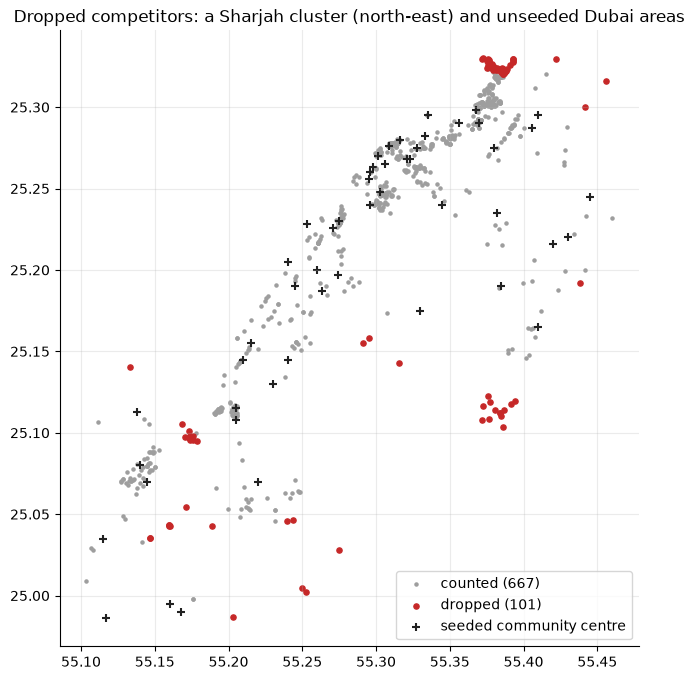

60 of 101 dropped are in the Sharjah corner (lat > 25.29, lng > 55.36)


In [11]:
# Where are the dropped ones? Most sit just over the border in Sharjah (the fetch used a
# rectangle, not the emirate boundary); the rest are in Dubai communities missing from the seed.
competitors["dropped"] = nearest_km > COMPETITOR_MAX_KM
fig, ax = plt.subplots(figsize=(8, 8))
kept, gone = competitors[~competitors.dropped], competitors[competitors.dropped]
ax.scatter(kept.lng, kept.lat, s=5, color="#9e9e9e", label=f"counted ({len(kept)})")
ax.scatter(gone.lng, gone.lat, s=14, color="#c62828", label=f"dropped ({len(gone)})")
ax.scatter(communities.lng, communities.lat, s=30, marker="+", color="#212121",
           label="seeded community centre")
ax.set_aspect(1 / 0.906)
ax.set_title("Dropped competitors: a Sharjah cluster (north-east) and unseeded Dubai areas")
ax.legend(loc="lower right")
plt.show()
sharjah = gone[(gone.lat > 25.29) & (gone.lng > 55.36)]
print(f"{len(sharjah)} of {len(gone)} dropped are in the Sharjah corner (lat > 25.29, lng > 55.36)")

### Everything on one map

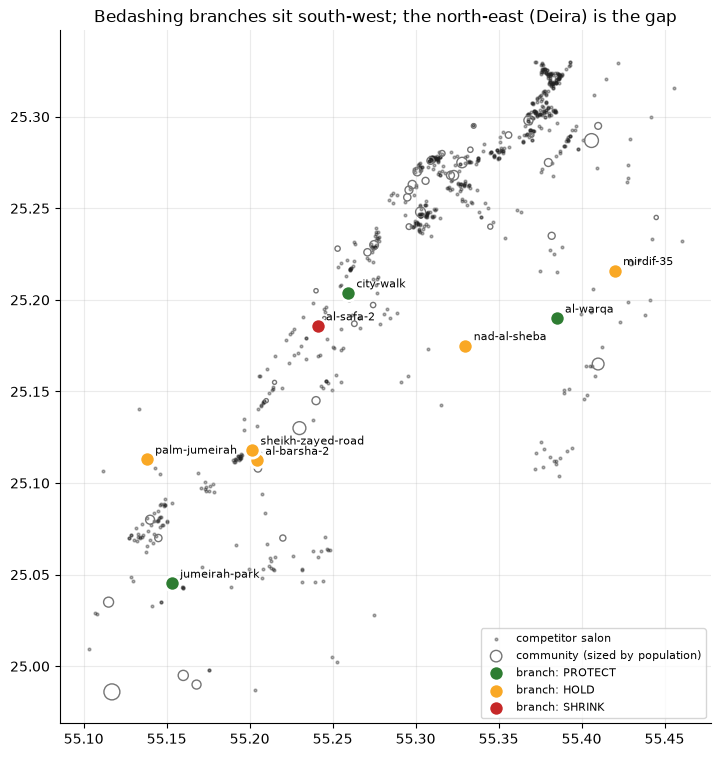

In [12]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(competitors.lng, competitors.lat, s=4, color="#212121", alpha=0.35, label="competitor salon")
ax.scatter(communities.lng, communities.lat, s=communities.population_total / 1500,
           facecolor="none", edgecolor="#757575", lw=1, label="community (sized by population)")
for action, color in ACTION.items():
    ids = [d.branch_id for d in data.decisions if d.action == action]
    b = branches[branches.id.isin(ids)]
    ax.scatter(b.lng, b.lat, s=120, color=color, edgecolor="white", lw=2, label=f"branch: {action}",
               zorder=3)
    for r in b.itertuples():
        ax.annotate(r.id, (r.lng, r.lat), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_aspect(1 / 0.906)   # cos(25°): keep distances honest
ax.set_title("Bedashing branches sit south-west; the north-east (Deira) is the gap")
ax.legend(loc="lower right", fontsize=8)
plt.show()

## 2. Catchments
Each community goes wholly to its straight-line nearest branch.

In [13]:
feat = pd.DataFrame([f.model_dump() for f in data.features]).set_index("branch_id")
dec = pd.DataFrame([d.model_dump() for d in data.decisions]).set_index("branch_id")
feat["action"] = dec.action
cols = ["female_pop_served", "communities_served", "mean_distance_km", "max_distance_km",
        "contested_share", "competitors_per_10k", "rating", "action"]
feat[cols].sort_values("female_pop_served", ascending=False).round(2)

,female_pop_served,communities_served,mean_distance_km,max_distance_km,contested_share,competitors_per_10k,rating,action
branch_id,,,,,,,,
city-walk,393658,19,7.03,10.51,0.44,6.22,4.6,PROTECT
mirdif-35,254804,12,7.20,12.26,0.46,8.71,4.6,HOLD
jumeirah-park,225283,5,6.03,7.53,0.00,1.02,4.8,PROTECT
al-warqa,75826,3,3.52,6.86,0.13,3.30,4.7,PROTECT
sheikh-zayed-road,69631,2,3.16,3.16,1.00,1.72,NaN,HOLD
palm-jumeirah,42933,2,2.62,3.67,0.71,7.69,4.9,HOLD
al-barsha-2,42648,3,1.95,4.97,0.33,16.18,4.7,HOLD
al-safa-2,35133,3,4.00,4.54,0.87,10.53,4.6,SHRINK
nad-al-sheba,3229,1,0.00,0.00,0.00,3.10,4.6,HOLD


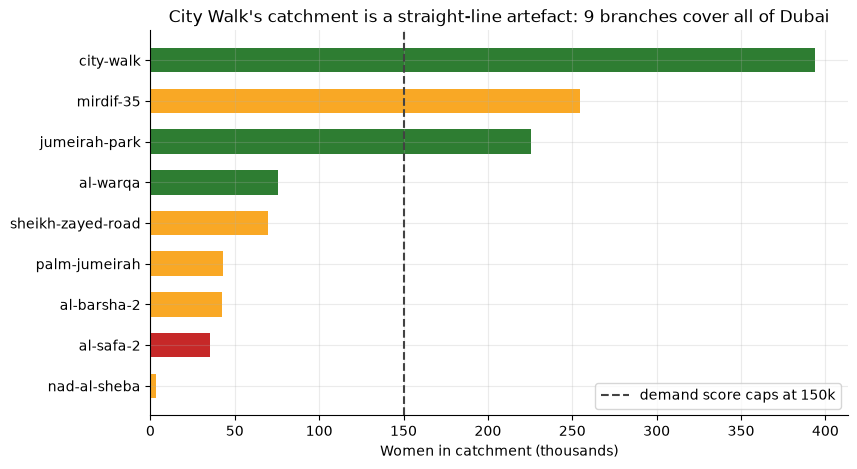

In [14]:
fig, ax = plt.subplots()
s = feat.sort_values("female_pop_served")
ax.barh(s.index, s.female_pop_served / 1000, color=[ACTION[a] for a in s.action], height=0.6)
ax.axvline(rubric.SIGNALS[0].best / 1000, color="#424242", ls="--", lw=1.5,
           label="demand score caps at 150k")
ax.set_xlabel("Women in catchment (thousands)")
ax.set_title("City Walk's catchment is a straight-line artefact: 9 branches cover all of Dubai")
ax.legend(loc="lower right")
plt.show()

## 3. Branch scores

In [15]:
scores = pd.DataFrame({d.branch_id: d.scores for d in data.decisions}).T
scores["composite"] = dec.composite
scores["action"] = dec.action
scores["confidence"] = dec.confidence
scores.sort_values("composite", ascending=False).round(2)

,demand,cannibalisation,competition,quality,composite,action,confidence
jumeirah-park,1.00,1.00,0.93,0.8,0.93,PROTECT,high
al-warqa,0.51,0.87,0.78,0.7,0.71,PROTECT,medium
city-walk,1.00,0.56,0.59,0.6,0.69,PROTECT,low
mirdif-35,1.00,0.54,0.42,0.6,0.64,HOLD,low
nad-al-sheba,0.02,1.00,0.79,0.6,0.60,HOLD,low
palm-jumeirah,0.29,0.29,0.49,0.9,0.49,HOLD,high
sheikh-zayed-road,0.46,0.00,0.89,0.5,0.46,HOLD,low
al-barsha-2,0.28,0.67,0.00,0.7,0.41,HOLD,medium
al-safa-2,0.23,0.13,0.30,0.6,0.31,SHRINK,low


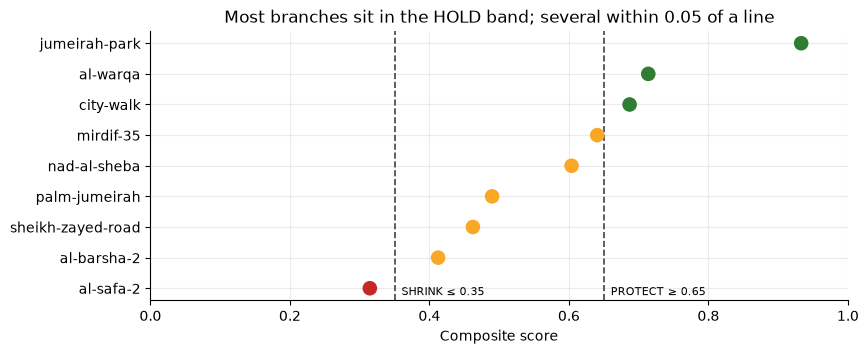

In [16]:
fig, ax = plt.subplots(figsize=(9, 3.5))
c = scores.sort_values("composite")
ax.scatter(c.composite, range(len(c)), s=90, color=[ACTION[a] for a in c.action], zorder=3)
ax.set_yticks(range(len(c)), c.index)
for x, label in ((rubric.SHRINK_AT, "SHRINK ≤"), (rubric.PROTECT_AT, "PROTECT ≥")):
    ax.axvline(x, color="#424242", ls="--", lw=1.2)
    ax.text(x + 0.01, 0.02, f"{label} {x}", transform=ax.get_xaxis_transform(), fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("Composite score")
ax.set_title("Most branches sit in the HOLD band; several within 0.05 of a line")
plt.show()

In [17]:
# Equal weights let strong signals hide a fatal one: low demand, but not SHRINK.
scores[scores.demand < 0.1][["demand", "cannibalisation", "competition", "quality", "composite", "action"]]

,demand,cannibalisation,competition,quality,composite,action
nad-al-sheba,0.0215,1.0,0.7935,0.6,0.6038,HOLD


## 4. Areas: the 2×2 and what's left

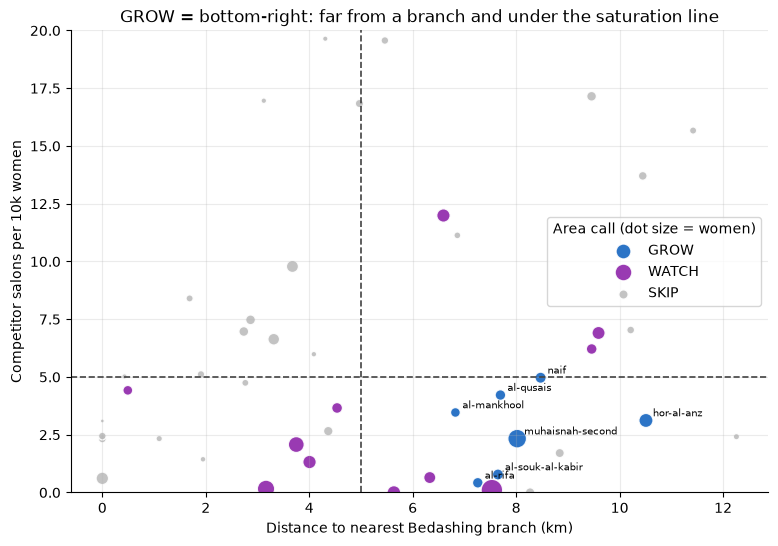

Not shown (over 20 per 10k): al-nahda-second (36, WATCH), al-barsha-second (45, SKIP), al-twar-first (34, SKIP), al-safa-first (36, SKIP)


In [18]:
cf = pd.DataFrame([c.model_dump() for c in data.community_features]).set_index("community_id")
op = pd.DataFrame([o.model_dump() for o in data.opportunities]).set_index("community_id")
areas = cf.join(op[["action", "salon_headroom", "uncovered_women", "fair_share", "captured_women_est"]])
fig, ax = plt.subplots(figsize=(9, 6))
for action, color in AREA.items():
    a = areas[areas.action == action]
    ax.scatter(a.nearest_branch_km, a.competitors_per_10k, s=a.female_pop / 400,
               color=color, edgecolor="white", lw=1, label=action, alpha=0.9)
ax.axvline(opportunity.FAR_KM, color="#424242", ls="--", lw=1.2)
ax.axhline(opportunity.UNSATURATED_PER_10K, color="#424242", ls="--", lw=1.2)
YMAX = 20
off_chart = areas[areas.competitors_per_10k > YMAX]
ax.set_ylim(0, YMAX)
ax.set_xlabel("Distance to nearest Bedashing branch (km)")
ax.set_ylabel("Competitor salons per 10k women")
ax.set_title("GROW = bottom-right: far from a branch and under the saturation line")
ax.legend(title="Area call (dot size = women)")
for cid, r in areas[areas.action == "GROW"].iterrows():
    ax.annotate(cid, (r.nearest_branch_km, r.competitors_per_10k), xytext=(5, 3),
                textcoords="offset points", fontsize=7)
plt.show()
print(f"Not shown (over {YMAX} per 10k):", ", ".join(
    f"{cid} ({v:.0f}, {a})" for cid, v, a in zip(off_chart.index, off_chart.competitors_per_10k,
                                                 off_chart.action)))

In [19]:
areas[areas.action != "SKIP"].sort_values(["action", "salon_headroom"], ascending=[True, False])[
    ["name", "action", "female_pop", "competitors", "competitors_per_10k", "nearest_branch_km",
     "salon_headroom", "uncovered_women"]].round(2)

,name,action,female_pop,competitors,competitors_per_10k,nearest_branch_km,salon_headroom,uncovered_women
community_id,,,,,,,,
muhaisnah-second,Muhaisnah Second,GROW,72928,17,2.33,8.02,19,72928
al-souk-al-kabir,Al Souk Al Kabir,GROW,25695,2,0.78,7.65,11,25695
al-rifa,Al Rifa,GROW,23788,1,0.42,7.26,11,23788
hor-al-anz,Hor Al Anz,GROW,41689,13,3.12,10.51,8,41689
al-mankhool,Al Mankhool,GROW,20210,7,3.46,6.83,3,20210
al-qusais,Al Qusais,GROW,23705,10,4.22,7.70,2,23705
naif,Naif,GROW,26167,13,4.97,8.47,0,26167
jebel-ali-industrial-first,Jebel Ali Industrial First,WATCH,97132,1,0.10,7.53,48,97132
al-quoz-industrial-second,Al Quoz Industrial Second,WATCH,63145,1,0.16,3.16,31,0


In [20]:
print("Total salon headroom in GROW areas:", areas.loc[areas.action == "GROW", "salon_headroom"].sum())
print("GROW areas with no headroom left:",
      areas.index[(areas.action == "GROW") & (areas.salon_headroom == 0)].tolist())

Total salon headroom in GROW areas: 54
GROW areas with no headroom left: ['naif']


## 5. How sensitive are the calls?
Re-classify with each threshold nudged, and count the calls that flip.

In [21]:
def branch_flips(protect, shrink):
    new = scores.composite.map(lambda c: "PROTECT" if c >= protect else "SHRINK" if c <= shrink else "HOLD")
    return int((new != scores.action).sum())

def area_flips(far_km, sat):
    keep = ~(areas.hosts_branch | (areas.female_pop < opportunity.MIN_POP))
    under, unsat = areas.nearest_branch_km > far_km, areas.competitors_per_10k < sat
    new = (under & unsat).map({True: "GROW", False: None}).fillna((under | unsat).map({True: "WATCH", False: "SKIP"}))
    new = new.where(keep, "SKIP")
    capped = areas.name.str.contains("Industrial|Investment Park", case=False) & (new == "GROW")
    new = new.where(~capped, "WATCH")
    return int((new != areas.action).sum())

rows = [("branch PROTECT line", f"{p:.2f}", branch_flips(p, rubric.SHRINK_AT)) for p in (0.60, 0.65, 0.70)]
rows += [("branch SHRINK line", f"{s:.2f}", branch_flips(rubric.PROTECT_AT, s)) for s in (0.30, 0.35, 0.40)]
rows += [("area distance line (km)", k, area_flips(k, opportunity.UNSATURATED_PER_10K)) for k in (4, 5, 6)]
rows += [("area saturation line (/10k)", t, area_flips(opportunity.FAR_KM, t)) for t in (4, 5, 6)]
pd.DataFrame(rows, columns=["threshold", "value", "calls that change"])

,threshold,value,calls that change
0,branch PROTECT line,0.60,2
1,branch PROTECT line,0.65,0
2,branch PROTECT line,0.70,1
3,branch SHRINK line,0.30,1
4,branch SHRINK line,0.35,0
5,branch SHRINK line,0.40,0
6,area distance line (km),4,2
7,area distance line (km),5,0
8,area distance line (km),6,0
9,area saturation line (/10k),4,3


## 6. Open questions this raises

Fill in as you go. Starting list from the checks above:

1. **Community coordinates have no recorded source.** Where did each centroid come from?
2. **Competitors outside every community are dropped (101 of 768).** About 60 are in Sharjah
   and rightly excluded. The other ~40 are in Dubai communities the seed doesn't have
   (around 25.1N 55.4E and 25.0-25.1N 55.2E), so competition there is undercounted.
   Adding those communities would fix it.
3. **Industrial areas dominate population** but are mostly male workers. The 49% female
   share is worst exactly where the population is largest.
4. **Branches within 1 km of each other** (section 1) will always score high on
   cannibalisation: is that real overlap or one branch listed twice?
5. **Threshold sensitivity** (section 5): any threshold where a small nudge flips several
   calls needs a stated reason, or a range instead of a line.